# Step 1: Import Required Libraries

In [89]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 2: Load Data

In [11]:
# Load climate data

folder_path = r'D:/Pasture Growth/datasets/'

climate_data = pd.concat([
    pd.read_csv(f'{folder_path}climate_{year}.csv') for year in range(2017, 2023)
])

climate_data.head()

,PADDOCK_ID,DATE,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION
0,E5BEE111190304432B4EEFB0B7FA23A7C23CF8960E4C7F...,2017-03-22,50.2,28.4,18.8,61.3,100.0,3.8,16.4
1,4C2EB78791FD1F9A42113DA94A14C1190BD8FBB8E87F96...,2017-03-22,52.5,28.5,18.9,61.2,100.0,3.8,16.3
2,9C2AE9804DFBFDFA6791C03D9FCE5DCBF9DA6AE7476477...,2017-03-22,52.5,28.5,18.9,61.2,100.0,3.8,16.3
3,04C1E345BBF76EA3E2B076C7E1E17290AD77F6BD159AD7...,2017-03-22,52.5,28.5,18.9,61.2,100.0,3.8,16.3
4,9F7943EC335457BE4BF1A456EC8AE9567902A02B4173C8...,2017-03-22,52.5,28.5,18.9,61.2,100.0,3.8,16.3


In [12]:
climate_data.shape

(33276908, 9)

In [13]:
# Load TSDM data

tsdm_data = pd.read_csv(r'D:\Pasture Growth\datasets\nrm1010_tsdm.csv')

tsdm_data.head()

,PADDOCK_ID,OBSERVATION_DATE,TSDM_MEAN
0,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,5/01/2017,1585.000000
1,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,20/01/2017,1620.333333
2,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,4/02/2017,1850.500000
3,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,19/02/2017,2303.000000
4,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,6/03/2017,2330.000000


In [14]:
tsdm_data.shape

(1030320, 3)

In [15]:
# Load paddock metadata

paddock_metadata = pd.read_csv(r'D:\Pasture Growth\datasets\paddock_metadata.csv')

paddock_metadata.head()

,PADDOCK_ID,CROP_TYPE,LANDSIZE_HA,PASTURE_STATE,CREATION_DATE
0,0AE10585CD37DE9A5DF983CF95D7237D534E6CE7EB6081...,natural grasses,29.90,Grazing,2019-08-11 01:58:53.388 Z
1,ED2AAAB2838D848AC4E7BDE8BA13941B7105ECF65DF3F4...,natural grasses,16.15,Grazing,2022-07-25 00:00:18.482 Z
2,435141E0BE1DBFD4E37DC6E374B4BD4C6D91CFC722E73A...,natural grasses,8.27,Grazing,2021-05-05 01:52:29.342 Z
3,AD6846319B84A902CB0B71B3F640643FCDA283D84B2DE8...,natural grasses,22.07,Grazing,2022-07-24 23:51:39.140 Z
4,7A85B8453613D37697502D75F3DBD922FBEE91FC6AB8A8...,natural grasses,0.82,Laneway,2022-07-25 00:21:57.661 Z


In [16]:
paddock_metadata.shape

(17966, 5)

# Step 3: Data Preprocessing & EDA

In [17]:
# Convert DATE to datetime format

climate_data['DATE'] = pd.to_datetime(climate_data['DATE'], format='%Y-%m-%d') 

tsdm_data['OBSERVATION_DATE'] = pd.to_datetime(tsdm_data['OBSERVATION_DATE'], dayfirst=True)

In [18]:
# Check unique values in PASTURE_STATE column

print(paddock_metadata['PASTURE_STATE'].unique())

['Grazing' 'Laneway' 'Yard' 'Cropping' 'Feedlot' 'Vegetation' 'Hay' 'Pen']


In [19]:
# Filter the DataFrame where PASTURE_STATE is 'Grazing'

paddock_metadata = paddock_metadata[paddock_metadata['PASTURE_STATE'] == 'Grazing']

In [20]:
print(paddock_metadata['PASTURE_STATE'].unique())

['Grazing']


In [21]:
paddock_metadata.shape

(14956, 5)

In [22]:
# Convert PADDOCK_ID to lowercase for consistency

tsdm_data['PADDOCK_ID'] = tsdm_data['PADDOCK_ID'].str.lower()
climate_data['PADDOCK_ID'] = climate_data['PADDOCK_ID'].str.lower()
paddock_metadata['PADDOCK_ID'] = paddock_metadata['PADDOCK_ID'].str.lower()

# Strip spaces or special characters from PADDOCK_ID

tsdm_data['PADDOCK_ID'] = tsdm_data['PADDOCK_ID'].str.strip()
climate_data['PADDOCK_ID'] = climate_data['PADDOCK_ID'].str.strip()
paddock_metadata['PADDOCK_ID'] = paddock_metadata['PADDOCK_ID'].str.strip()

# Common PADDOCK_ID values across all three datasets

common_ids_tsdm_climate = set(tsdm_data['PADDOCK_ID']).intersection(set(climate_data['PADDOCK_ID']))
common_ids_all = common_ids_tsdm_climate.intersection(set(paddock_metadata['PADDOCK_ID']))

# Number of common PADDOCK_IDs

print(f"Number of common PADDOCK_IDs between TSDM and Climate data: {len(common_ids_tsdm_climate)}")
print(f"Number of common PADDOCK_IDs across all datasets: {len(common_ids_all)}")

Number of common PADDOCK_IDs between TSDM and Climate data: 4855
Number of common PADDOCK_IDs across all datasets: 4808


In [23]:
# Merge TSDM data with Climate data

merged_data = pd.merge(tsdm_data, climate_data, 
                       left_on=['PADDOCK_ID', 'OBSERVATION_DATE'], 
                       right_on=['PADDOCK_ID', 'DATE'], 
                       how='inner')

# Merge with paddock metadata

merged_data = pd.merge(merged_data, paddock_metadata, 
                       on='PADDOCK_ID', 
                       how='inner')

merged_data.head()

,PADDOCK_ID,OBSERVATION_DATE,TSDM_MEAN,DATE,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,CROP_TYPE,LANDSIZE_HA,PASTURE_STATE,CREATION_DATE
0,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-05,1585.000000,2017-01-05,0.0,31.9,17.4,35.7,85.1,7.0,26.7,lucerne,35.33,Grazing,2022-06-27 05:38:25.679 Z
1,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-20,1620.333333,2017-01-20,0.1,31.0,18.2,51.6,100.0,8.9,12.8,lucerne,35.33,Grazing,2022-06-27 05:38:25.679 Z
2,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-04,1850.500000,2017-02-04,0.0,39.3,21.9,34.9,94.4,5.8,22.8,lucerne,35.33,Grazing,2022-06-27 05:38:25.679 Z
3,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-19,2303.000000,2017-02-19,0.0,29.1,14.9,22.6,53.7,9.3,21.2,lucerne,35.33,Grazing,2022-06-27 05:38:25.679 Z
4,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-03-06,2330.000000,2017-03-06,0.2,29.8,14.6,44.8,100.0,4.7,21.2,lucerne,35.33,Grazing,2022-06-27 05:38:25.679 Z


In [24]:
merged_data.shape

(701968, 15)

In [25]:
# Remove the DATE and CREATION_DATE column from the merged_data 

merged_data.drop(columns=['DATE', 'CREATION_DATE'], inplace=True)

merged_data.columns

Index(['PADDOCK_ID', 'OBSERVATION_DATE', 'TSDM_MEAN', 'RAIN', 'MAX_TEMP',
       'MIN_TEMP', 'RH_TMAX', 'RH_TMIN', 'EVAP', 'RADIATION', 'CROP_TYPE',
       'LANDSIZE_HA', 'PASTURE_STATE'],
      dtype='object')

In [26]:
merged_data.head()

,PADDOCK_ID,OBSERVATION_DATE,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,CROP_TYPE,LANDSIZE_HA,PASTURE_STATE
0,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-05,1585.000000,0.0,31.9,17.4,35.7,85.1,7.0,26.7,lucerne,35.33,Grazing
1,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-20,1620.333333,0.1,31.0,18.2,51.6,100.0,8.9,12.8,lucerne,35.33,Grazing
2,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-04,1850.500000,0.0,39.3,21.9,34.9,94.4,5.8,22.8,lucerne,35.33,Grazing
3,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-19,2303.000000,0.0,29.1,14.9,22.6,53.7,9.3,21.2,lucerne,35.33,Grazing
4,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-03-06,2330.000000,0.2,29.8,14.6,44.8,100.0,4.7,21.2,lucerne,35.33,Grazing


In [27]:
merged_data.shape

(701968, 13)

In [28]:
merged_data.dtypes

PADDOCK_ID                  object
OBSERVATION_DATE    datetime64[ns]
TSDM_MEAN                  float64
RAIN                       float64
MAX_TEMP                   float64
MIN_TEMP                   float64
RH_TMAX                    float64
RH_TMIN                    float64
EVAP                       float64
RADIATION                  float64
CROP_TYPE                   object
LANDSIZE_HA                float64
PASTURE_STATE               object
dtype: object

In [29]:
print(merged_data['PASTURE_STATE'].unique())

['Grazing']


In [30]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701968 entries, 0 to 701967
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   PADDOCK_ID        701968 non-null  object        
 1   OBSERVATION_DATE  701968 non-null  datetime64[ns]
 2   TSDM_MEAN         687426 non-null  float64       
 3   RAIN              701968 non-null  float64       
 4   MAX_TEMP          701968 non-null  float64       
 5   MIN_TEMP          701968 non-null  float64       
 6   RH_TMAX           701968 non-null  float64       
 7   RH_TMIN           701968 non-null  float64       
 8   EVAP              701968 non-null  float64       
 9   RADIATION         701968 non-null  float64       
 10  CROP_TYPE         701092 non-null  object        
 11  LANDSIZE_HA       701968 non-null  float64       
 12  PASTURE_STATE     701968 non-null  object        
dtypes: datetime64[ns](1), float64(9), object(3)
memory usage: 6

In [31]:
# Count of missing values in each column

merged_data.isnull().sum() 

PADDOCK_ID              0
OBSERVATION_DATE        0
TSDM_MEAN           14542
RAIN                    0
MAX_TEMP                0
MIN_TEMP                0
RH_TMAX                 0
RH_TMIN                 0
EVAP                    0
RADIATION               0
CROP_TYPE             876
LANDSIZE_HA             0
PASTURE_STATE           0
dtype: int64

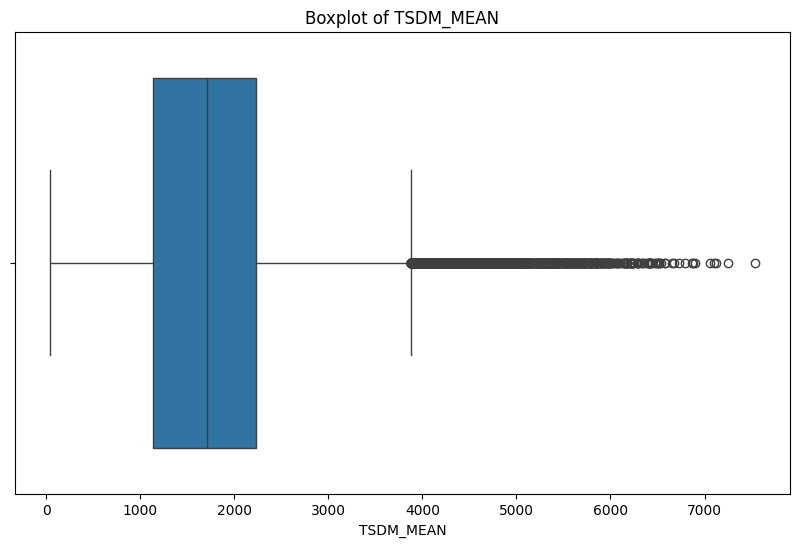

In [32]:
# Check for outlier in TSDM_MEAN column

plt.figure(figsize=(10, 6))
sns.boxplot(x=merged_data['TSDM_MEAN'])
plt.title('Boxplot of TSDM_MEAN')
plt.show()

In [33]:
# Impute missing TSDM_MEAN values with the median

merged_data['TSDM_MEAN'].fillna(merged_data['TSDM_MEAN'].median(), inplace=True)

In [34]:
# Count of missing values in each column

merged_data.isnull().sum()

PADDOCK_ID            0
OBSERVATION_DATE      0
TSDM_MEAN             0
RAIN                  0
MAX_TEMP              0
MIN_TEMP              0
RH_TMAX               0
RH_TMIN               0
EVAP                  0
RADIATION             0
CROP_TYPE           876
LANDSIZE_HA           0
PASTURE_STATE         0
dtype: int64

In [35]:
# Impute missing CROP_TYPE values with the mode

merged_data['CROP_TYPE'].fillna(merged_data['CROP_TYPE'].mode()[0], inplace=True)

In [36]:
# Count of missing values in each column

merged_data.isnull().sum()

PADDOCK_ID          0
OBSERVATION_DATE    0
TSDM_MEAN           0
RAIN                0
MAX_TEMP            0
MIN_TEMP            0
RH_TMAX             0
RH_TMIN             0
EVAP                0
RADIATION           0
CROP_TYPE           0
LANDSIZE_HA         0
PASTURE_STATE       0
dtype: int64

In [37]:
# check for stats

merged_data.describe()

,OBSERVATION_DATE,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,LANDSIZE_HA
count,701968,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000
mean,2019-12-28 12:00:00,1720.159833,1.979314,21.352619,8.203790,47.513938,94.562550,3.843573,16.239870,46.808850
min,2017-01-05 00:00:00,41.833333,0.000000,2.500000,-6.000000,11.800000,27.700000,0.000000,3.000000,0.000000
25%,2018-06-29 00:00:00,1151.583333,0.000000,15.500000,3.400000,35.400000,93.300000,1.900000,10.300000,25.749105
50%,2019-12-28 12:00:00,1708.714286,0.000000,20.700000,7.400000,46.900000,100.000000,3.200000,15.300000,34.019937
75%,2021-06-28 00:00:00,2223.285714,0.800000,26.900000,13.400000,58.100000,100.000000,5.300000,22.300000,49.987009
max,2022-12-20 00:00:00,7532.500000,70.800000,45.600000,27.000000,91.400000,100.000000,15.800000,34.300000,1512.900808
std,NaN,695.954315,5.666996,7.597632,6.186689,15.296876,10.601506,2.545202,7.097053,51.755748


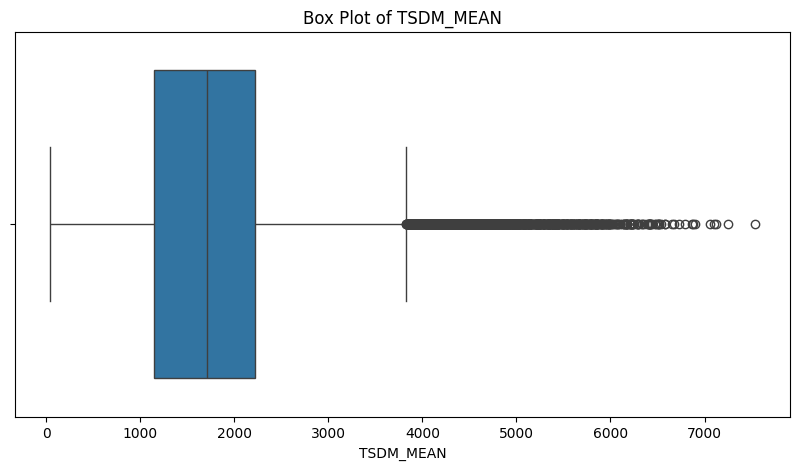

In [38]:
# Box Plot of TSDM_MEAN

plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_data['TSDM_MEAN'])
plt.title('Box Plot of TSDM_MEAN')
plt.xlabel('TSDM_MEAN')
plt.show()

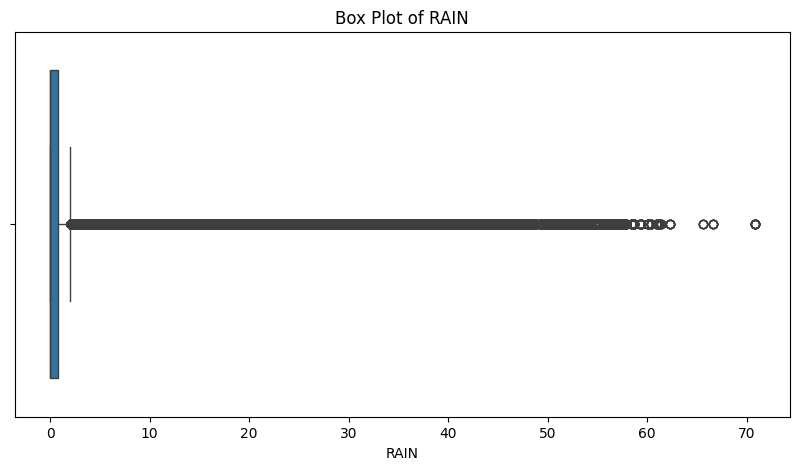

In [39]:
# Box Plot of RAIN

plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_data['RAIN'])
plt.title('Box Plot of RAIN')
plt.xlabel('RAIN')
plt.show()

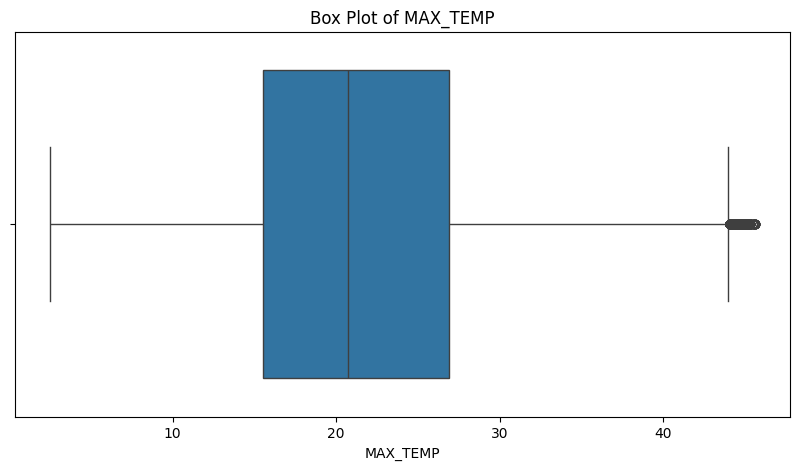

In [40]:
# Box Plot of MAX_TEMP

plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_data['MAX_TEMP'])
plt.title('Box Plot of MAX_TEMP')
plt.xlabel('MAX_TEMP')
plt.show()

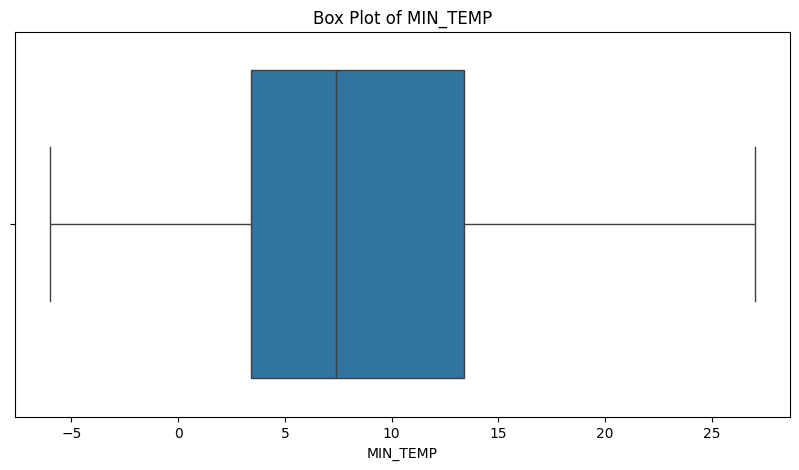

In [41]:
# Box Plot of MIN_TEMP

plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_data['MIN_TEMP'])
plt.title('Box Plot of MIN_TEMP')
plt.xlabel('MIN_TEMP')
plt.show()

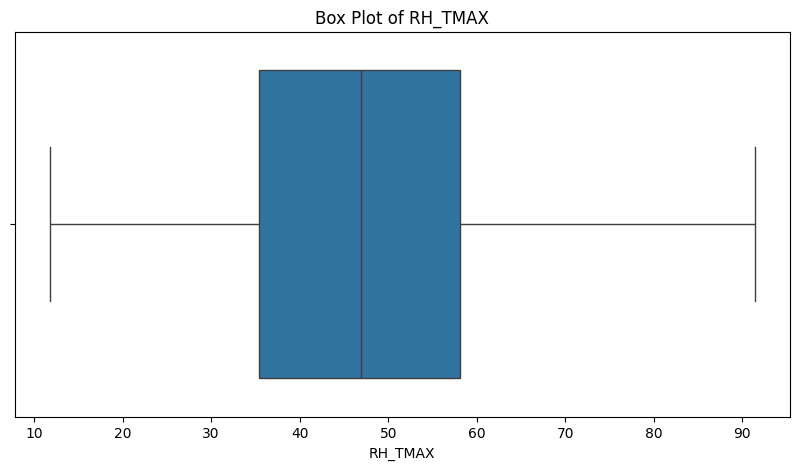

In [42]:
# Box Plot of RH_TMAX

plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_data['RH_TMAX'])
plt.title('Box Plot of RH_TMAX')
plt.xlabel('RH_TMAX')
plt.show()

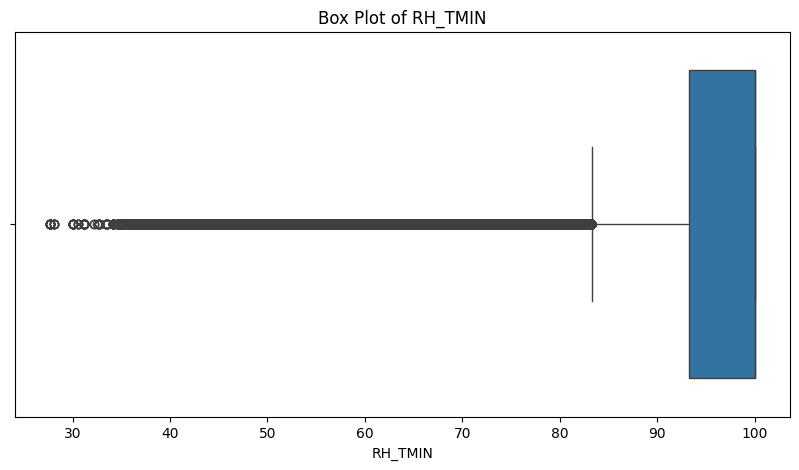

In [43]:
# Box Plot of RH_TMIN

plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_data['RH_TMIN'])
plt.title('Box Plot of RH_TMIN')
plt.xlabel('RH_TMIN')
plt.show()

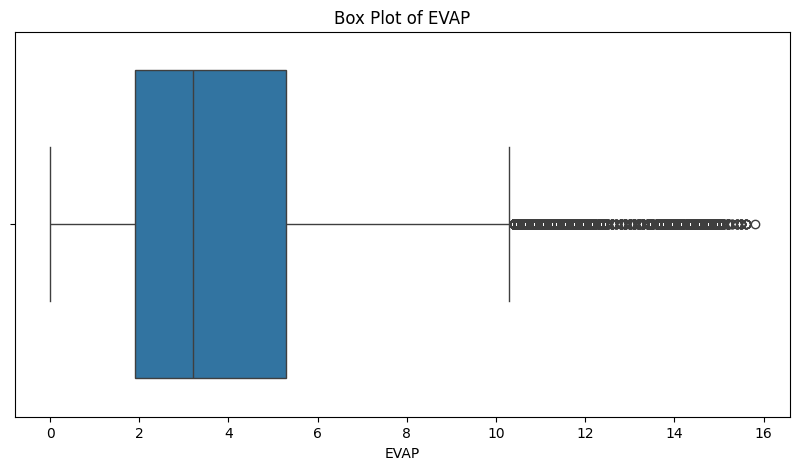

In [44]:
# Box Plot of EVAP

plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_data['EVAP'])
plt.title('Box Plot of EVAP')
plt.xlabel('EVAP')
plt.show()

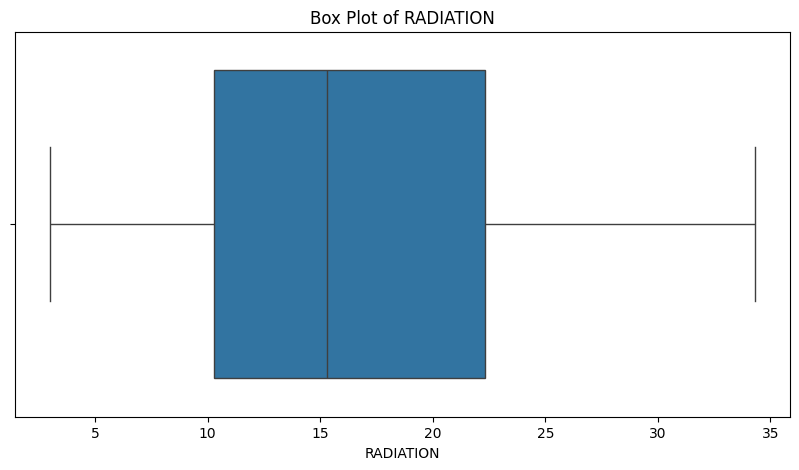

In [45]:
# Box Plot of RADIATION

plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_data['RADIATION'])
plt.title('Box Plot of RADIATION')
plt.xlabel('RADIATION')
plt.show()

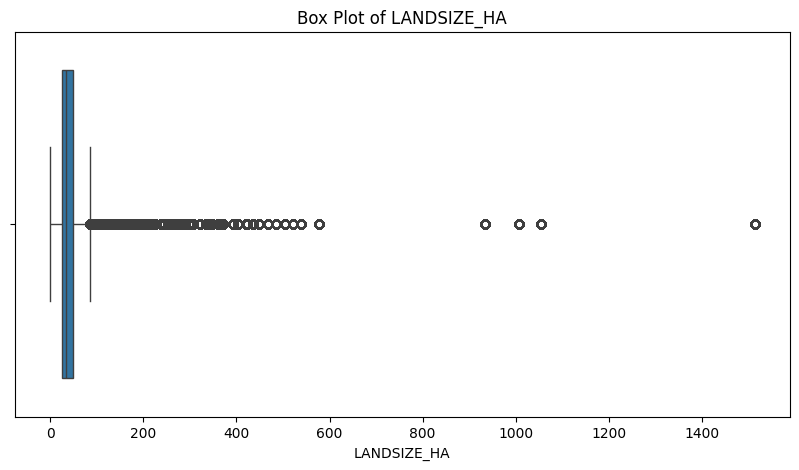

In [46]:
# Box Plot of LANDSIZE_HA

plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_data['LANDSIZE_HA'])
plt.title('Box Plot of LANDSIZE_HA')
plt.xlabel('LANDSIZE_HA')
plt.show()

In [47]:
merged_data.describe()

,OBSERVATION_DATE,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,LANDSIZE_HA
count,701968,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000
mean,2019-12-28 12:00:00,1720.159833,1.979314,21.352619,8.203790,47.513938,94.562550,3.843573,16.239870,46.808850
min,2017-01-05 00:00:00,41.833333,0.000000,2.500000,-6.000000,11.800000,27.700000,0.000000,3.000000,0.000000
25%,2018-06-29 00:00:00,1151.583333,0.000000,15.500000,3.400000,35.400000,93.300000,1.900000,10.300000,25.749105
50%,2019-12-28 12:00:00,1708.714286,0.000000,20.700000,7.400000,46.900000,100.000000,3.200000,15.300000,34.019937
75%,2021-06-28 00:00:00,2223.285714,0.800000,26.900000,13.400000,58.100000,100.000000,5.300000,22.300000,49.987009
max,2022-12-20 00:00:00,7532.500000,70.800000,45.600000,27.000000,91.400000,100.000000,15.800000,34.300000,1512.900808
std,NaN,695.954315,5.666996,7.597632,6.186689,15.296876,10.601506,2.545202,7.097053,51.755748


In [48]:
merged_data.head()

,PADDOCK_ID,OBSERVATION_DATE,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,CROP_TYPE,LANDSIZE_HA,PASTURE_STATE
0,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-05,1585.000000,0.0,31.9,17.4,35.7,85.1,7.0,26.7,lucerne,35.33,Grazing
1,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-20,1620.333333,0.1,31.0,18.2,51.6,100.0,8.9,12.8,lucerne,35.33,Grazing
2,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-04,1850.500000,0.0,39.3,21.9,34.9,94.4,5.8,22.8,lucerne,35.33,Grazing
3,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-19,2303.000000,0.0,29.1,14.9,22.6,53.7,9.3,21.2,lucerne,35.33,Grazing
4,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-03-06,2330.000000,0.2,29.8,14.6,44.8,100.0,4.7,21.2,lucerne,35.33,Grazing


In [49]:
# Function to cap outliers using IQR

def cap_outliers_iqr(merged_data):
   
    exclude_cols = ['MIN_TEMP', 'RH_TMAX', 'RADIATION']

    # Iterate over each numerical column in the DataFrame
    for col in merged_data.select_dtypes(include=['float64']).columns:
        
        # Skip the columns that are in the exclude list
        if col in exclude_cols:
            continue

        Q1 = merged_data[col].quantile(0.25) 
        Q3 = merged_data[col].quantile(0.75)  
        IQR = Q3 - Q1 

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        print(f"Column: {col}")
        print(f"  Q1: {Q1}")
        print(f"  Q3: {Q3}")
        print(f"  IQR: {IQR}")
        print(f"  Lower Bound: {lower_bound}")
        print(f"  Upper Bound: {upper_bound}")
        
        # Cap the outliers using clip
        merged_data[col] = merged_data[col].clip(lower=lower_bound, upper=upper_bound)
    
    return merged_data

final_merge = cap_outliers_iqr(merged_data)  

Column: TSDM_MEAN
  Q1: 1151.5833333333333
  Q3: 2223.285714285714
  IQR: 1071.702380952381
  Lower Bound: -455.9702380952383
  Upper Bound: 3830.839285714286
Column: RAIN
  Q1: 0.0
  Q3: 0.8
  IQR: 0.8
  Lower Bound: -1.2000000000000002
  Upper Bound: 2.0
Column: MAX_TEMP
  Q1: 15.5
  Q3: 26.9
  IQR: 11.399999999999999
  Lower Bound: -1.5999999999999979
  Upper Bound: 44.0
Column: RH_TMIN
  Q1: 93.3
  Q3: 100.0
  IQR: 6.700000000000003
  Lower Bound: 83.25
  Upper Bound: 110.05000000000001
Column: EVAP
  Q1: 1.9
  Q3: 5.3
  IQR: 3.4
  Lower Bound: -3.1999999999999997
  Upper Bound: 10.399999999999999
Column: LANDSIZE_HA
  Q1: 25.749104597749998
  Q3: 49.98700938925
  IQR: 24.2379047915
  Lower Bound: -10.607752589500002
  Upper Bound: 86.3438665765


In [50]:
final_merge.head()

,PADDOCK_ID,OBSERVATION_DATE,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,CROP_TYPE,LANDSIZE_HA,PASTURE_STATE
0,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-05,1585.000000,0.0,31.9,17.4,35.7,85.10,7.0,26.7,lucerne,35.33,Grazing
1,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-20,1620.333333,0.1,31.0,18.2,51.6,100.00,8.9,12.8,lucerne,35.33,Grazing
2,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-04,1850.500000,0.0,39.3,21.9,34.9,94.40,5.8,22.8,lucerne,35.33,Grazing
3,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-19,2303.000000,0.0,29.1,14.9,22.6,83.25,9.3,21.2,lucerne,35.33,Grazing
4,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-03-06,2330.000000,0.2,29.8,14.6,44.8,100.00,4.7,21.2,lucerne,35.33,Grazing


In [51]:
final_merge.describe()

,OBSERVATION_DATE,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,LANDSIZE_HA
count,701968,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000,701968.000000
mean,2019-12-28 12:00:00,1718.284044,0.490724,21.352095,8.203790,47.513938,96.123680,3.806794,16.239870,40.996830
min,2017-01-05 00:00:00,41.833333,0.000000,2.500000,-6.000000,11.800000,83.250000,0.000000,3.000000,0.000000
25%,2018-06-29 00:00:00,1151.583333,0.000000,15.500000,3.400000,35.400000,93.300000,1.900000,10.300000,25.749105
50%,2019-12-28 12:00:00,1708.714286,0.000000,20.700000,7.400000,46.900000,100.000000,3.200000,15.300000,34.019937
75%,2021-06-28 00:00:00,2223.285714,0.800000,26.900000,13.400000,58.100000,100.000000,5.300000,22.300000,49.987009
max,2022-12-20 00:00:00,3830.839286,2.000000,44.000000,27.000000,91.400000,100.000000,10.400000,34.300000,86.343867
std,NaN,688.505806,0.795765,7.596043,6.186689,15.296876,6.130359,2.424331,7.097053,19.849741


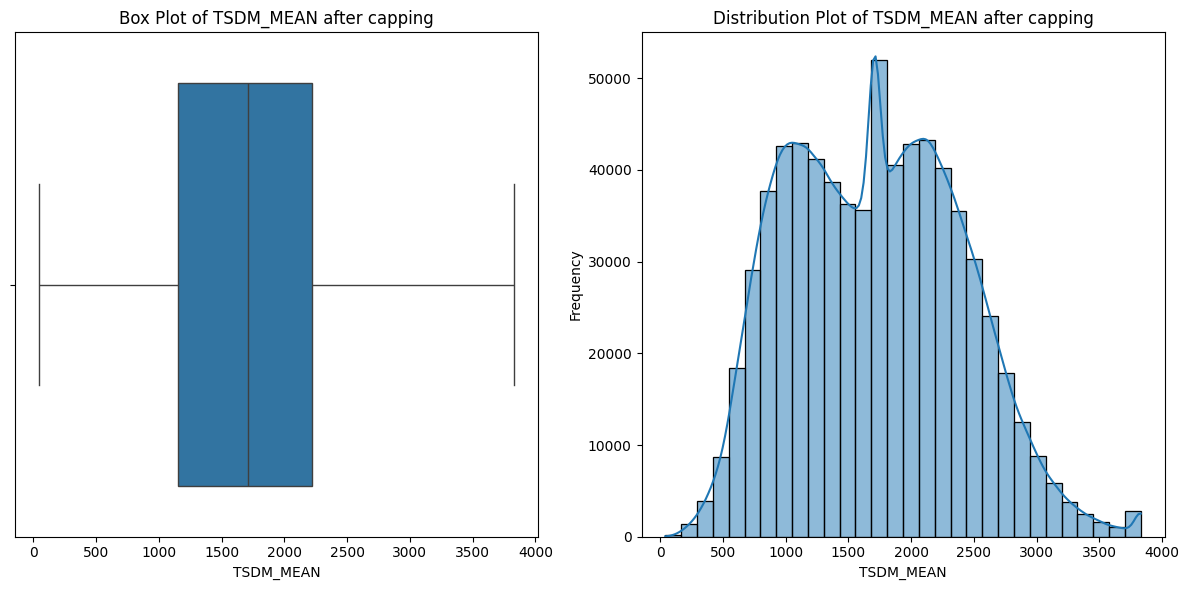

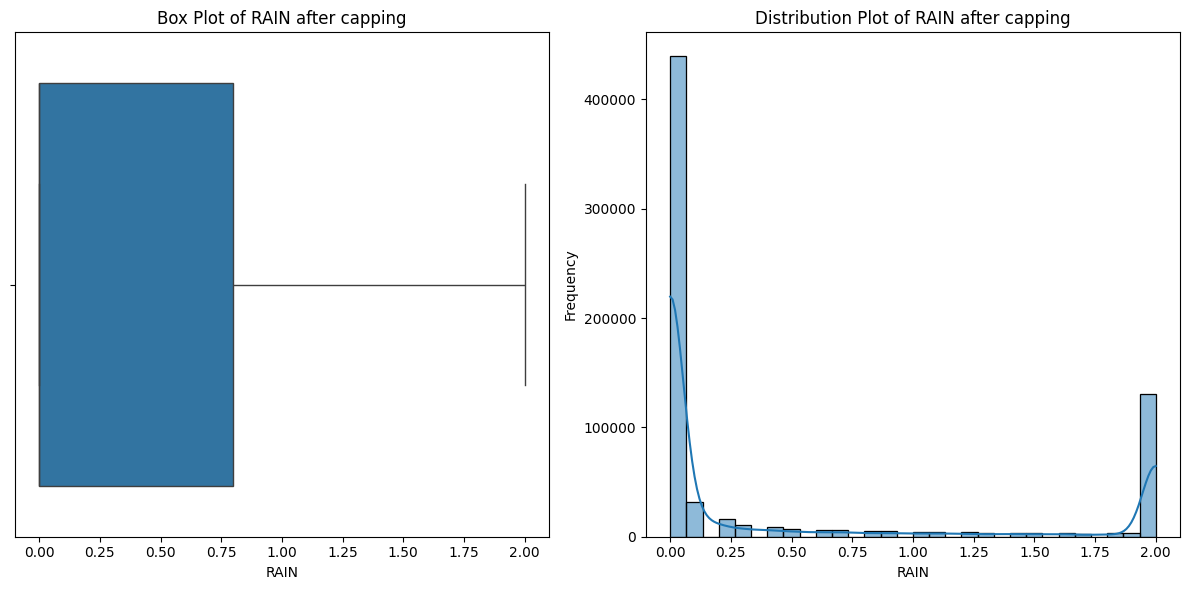

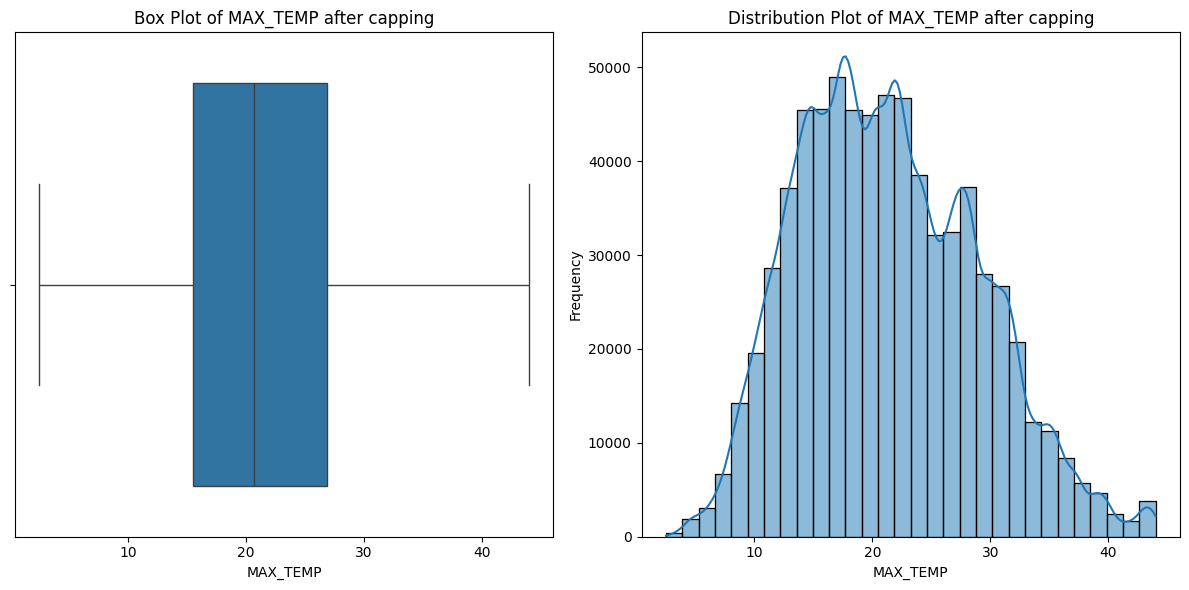

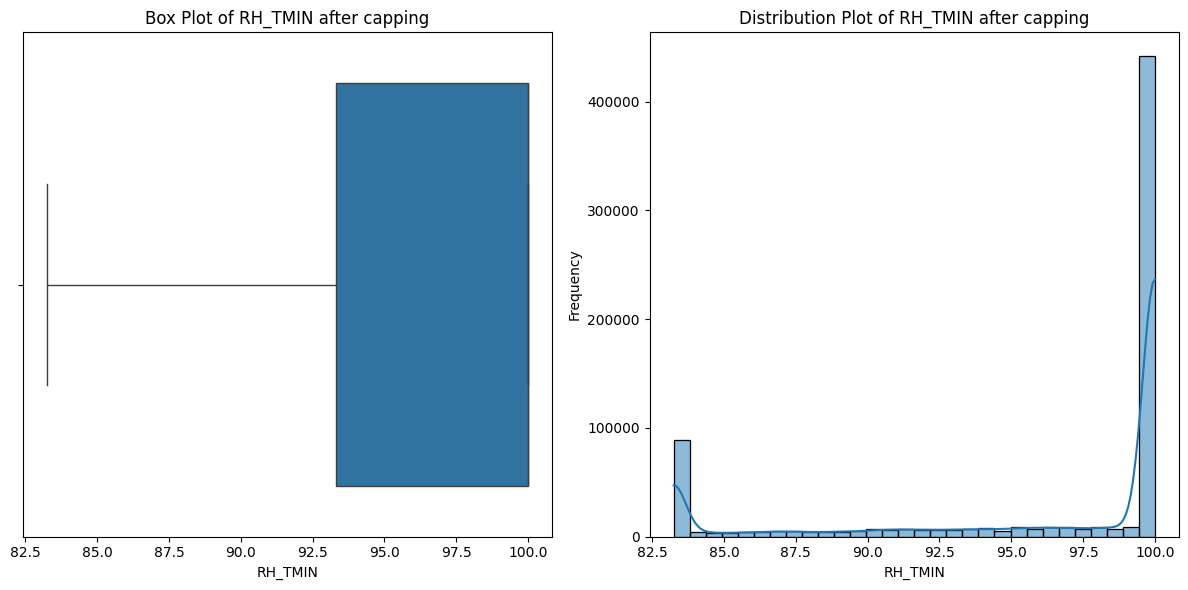

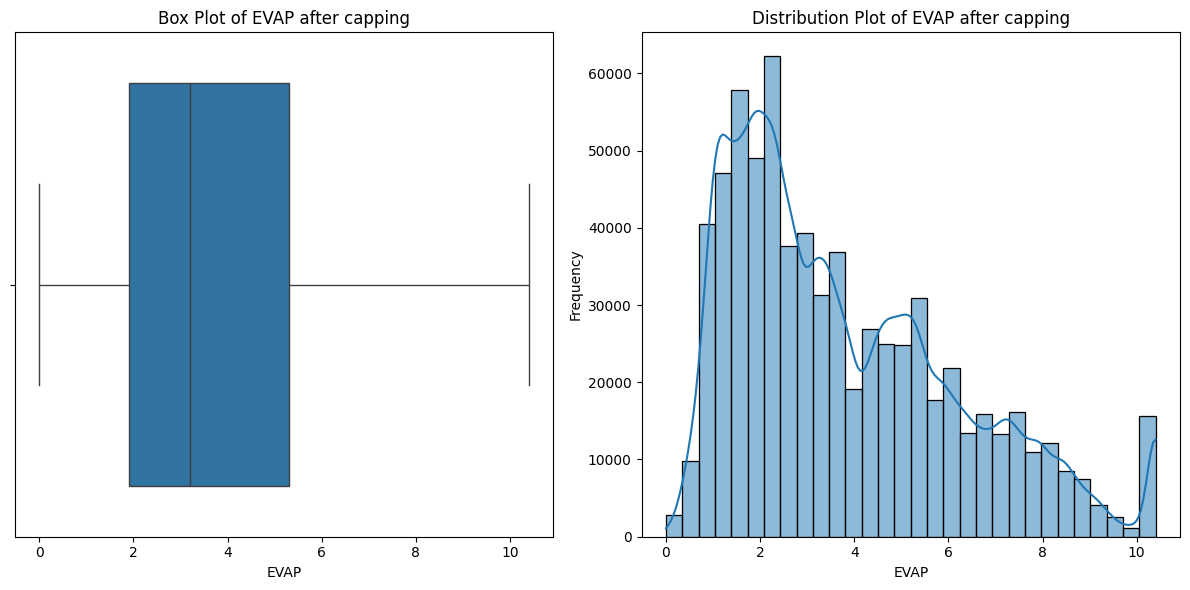

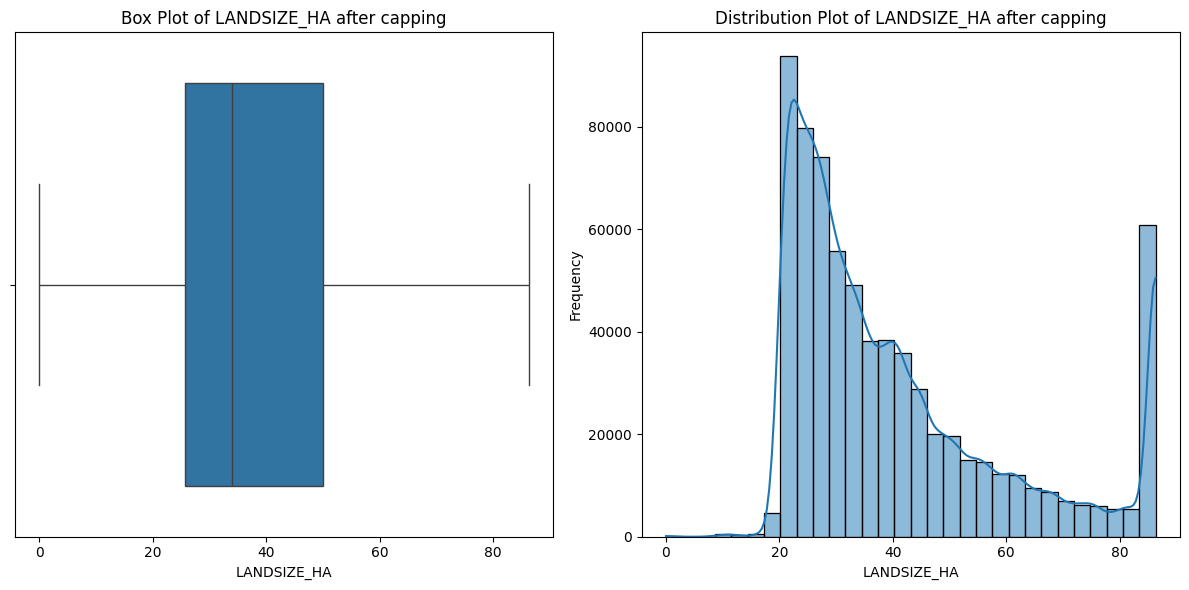

In [52]:
# Define the columns to plot

columns_to_plot = ['TSDM_MEAN', 'RAIN', 'MAX_TEMP', 'RH_TMIN', 'EVAP', 'LANDSIZE_HA']

# Create box plots and distribution plots after capping

for column in columns_to_plot:
    plt.figure(figsize=(12, 6))

    # Box Plot
    plt.subplot(1, 2, 1)
    sns.boxplot(x=merged_data[column])
    plt.title(f'Box Plot of {column} after capping')
    plt.xlabel(column)

    # Distribution Plot
    plt.subplot(1, 2, 2)
    sns.histplot(merged_data[column], kde=True, bins=30)
    plt.title(f'Distribution Plot of {column} after capping')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# Step 4: Feature Engineering

### 4.1 Date Features

In [53]:
# Convert 'OBSERVATION_DATE' to datetime
final_merge['OBSERVATION_DATE'] = pd.to_datetime(final_merge['OBSERVATION_DATE'])

# Extracting features from the date
final_merge['Year'] = final_merge['OBSERVATION_DATE'].dt.year
final_merge['Month'] = final_merge['OBSERVATION_DATE'].dt.month
final_merge['Day'] = final_merge['OBSERVATION_DATE'].dt.day
final_merge['Weekday'] = final_merge['OBSERVATION_DATE'].dt.weekday  # Monday=0, Sunday=6

In [54]:
final_merge.head()

,PADDOCK_ID,OBSERVATION_DATE,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,CROP_TYPE,LANDSIZE_HA,PASTURE_STATE,Year,Month,Day,Weekday
0,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-05,1585.000000,0.0,31.9,17.4,35.7,85.10,7.0,26.7,lucerne,35.33,Grazing,2017,1,5,3
1,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-20,1620.333333,0.1,31.0,18.2,51.6,100.00,8.9,12.8,lucerne,35.33,Grazing,2017,1,20,4
2,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-04,1850.500000,0.0,39.3,21.9,34.9,94.40,5.8,22.8,lucerne,35.33,Grazing,2017,2,4,5
3,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-19,2303.000000,0.0,29.1,14.9,22.6,83.25,9.3,21.2,lucerne,35.33,Grazing,2017,2,19,6
4,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-03-06,2330.000000,0.2,29.8,14.6,44.8,100.00,4.7,21.2,lucerne,35.33,Grazing,2017,3,6,0


### 4.2 Ratio Features

In [55]:
# Creating ratio and difference features
final_merge['Rain_Evap_Ratio'] = final_merge['RAIN'] / (final_merge['EVAP'] + 1e-5)  # Adding a small value to avoid division by zero
final_merge['Temp_Range'] = final_merge['MAX_TEMP'] - final_merge['MIN_TEMP']

In [56]:
final_merge.head()

,PADDOCK_ID,OBSERVATION_DATE,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,CROP_TYPE,LANDSIZE_HA,PASTURE_STATE,Year,Month,Day,Weekday,Rain_Evap_Ratio,Temp_Range
0,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-05,1585.000000,0.0,31.9,17.4,35.7,85.10,7.0,26.7,lucerne,35.33,Grazing,2017,1,5,3,0.000000,14.5
1,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-20,1620.333333,0.1,31.0,18.2,51.6,100.00,8.9,12.8,lucerne,35.33,Grazing,2017,1,20,4,0.011236,12.8
2,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-04,1850.500000,0.0,39.3,21.9,34.9,94.40,5.8,22.8,lucerne,35.33,Grazing,2017,2,4,5,0.000000,17.4
3,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-19,2303.000000,0.0,29.1,14.9,22.6,83.25,9.3,21.2,lucerne,35.33,Grazing,2017,2,19,6,0.000000,14.2
4,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-03-06,2330.000000,0.2,29.8,14.6,44.8,100.00,4.7,21.2,lucerne,35.33,Grazing,2017,3,6,0,0.042553,15.2


### 4.3 Binning Features

In [57]:
# Binning features
final_merge['TSDM_Bin'] = pd.cut(final_merge['TSDM_MEAN'], bins=[0, 1000, 2000, 3000, 4000], labels=['Low', 'Medium', 'High', 'Very High'])
final_merge['Max_Temp_Bin'] = pd.cut(final_merge['MAX_TEMP'], bins=[0, 15, 30, 45], labels=['Cold', 'Warm', 'Hot'])

In [58]:
final_merge.head()

,PADDOCK_ID,OBSERVATION_DATE,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,...,LANDSIZE_HA,PASTURE_STATE,Year,Month,Day,Weekday,Rain_Evap_Ratio,Temp_Range,TSDM_Bin,Max_Temp_Bin
0,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-05,1585.000000,0.0,31.9,17.4,35.7,85.10,7.0,26.7,...,35.33,Grazing,2017,1,5,3,0.000000,14.5,Medium,Hot
1,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-20,1620.333333,0.1,31.0,18.2,51.6,100.00,8.9,12.8,...,35.33,Grazing,2017,1,20,4,0.011236,12.8,Medium,Hot
2,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-04,1850.500000,0.0,39.3,21.9,34.9,94.40,5.8,22.8,...,35.33,Grazing,2017,2,4,5,0.000000,17.4,Medium,Hot
3,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-19,2303.000000,0.0,29.1,14.9,22.6,83.25,9.3,21.2,...,35.33,Grazing,2017,2,19,6,0.000000,14.2,High,Warm
4,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-03-06,2330.000000,0.2,29.8,14.6,44.8,100.00,4.7,21.2,...,35.33,Grazing,2017,3,6,0,0.042553,15.2,High,Warm


In [59]:
final_merge.isnull().sum()

PADDOCK_ID          0
OBSERVATION_DATE    0
TSDM_MEAN           0
RAIN                0
MAX_TEMP            0
MIN_TEMP            0
RH_TMAX             0
RH_TMIN             0
EVAP                0
RADIATION           0
CROP_TYPE           0
LANDSIZE_HA         0
PASTURE_STATE       0
Year                0
Month               0
Day                 0
Weekday             0
Rain_Evap_Ratio     0
Temp_Range          0
TSDM_Bin            0
Max_Temp_Bin        0
dtype: int64

In [60]:
final_merge.columns

Index(['PADDOCK_ID', 'OBSERVATION_DATE', 'TSDM_MEAN', 'RAIN', 'MAX_TEMP',
       'MIN_TEMP', 'RH_TMAX', 'RH_TMIN', 'EVAP', 'RADIATION', 'CROP_TYPE',
       'LANDSIZE_HA', 'PASTURE_STATE', 'Year', 'Month', 'Day', 'Weekday',
       'Rain_Evap_Ratio', 'Temp_Range', 'TSDM_Bin', 'Max_Temp_Bin'],
      dtype='object')

In [61]:
final_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701968 entries, 0 to 701967
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   PADDOCK_ID        701968 non-null  object        
 1   OBSERVATION_DATE  701968 non-null  datetime64[ns]
 2   TSDM_MEAN         701968 non-null  float64       
 3   RAIN              701968 non-null  float64       
 4   MAX_TEMP          701968 non-null  float64       
 5   MIN_TEMP          701968 non-null  float64       
 6   RH_TMAX           701968 non-null  float64       
 7   RH_TMIN           701968 non-null  float64       
 8   EVAP              701968 non-null  float64       
 9   RADIATION         701968 non-null  float64       
 10  CROP_TYPE         701968 non-null  object        
 11  LANDSIZE_HA       701968 non-null  float64       
 12  PASTURE_STATE     701968 non-null  object        
 13  Year              701968 non-null  int32         
 14  Mont

### 4.4 Interaction Features

In [65]:
# Interaction feature

final_merge['Temp_Rain_Interaction'] = final_merge['MAX_TEMP'] * final_merge['RAIN']

In [66]:
final_merge.head()

,PADDOCK_ID,OBSERVATION_DATE,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,...,PASTURE_STATE,Year,Month,Day,Weekday,Rain_Evap_Ratio,Temp_Range,TSDM_Bin,Max_Temp_Bin,Temp_Rain_Interaction
0,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-05,1585.000000,0.0,31.9,17.4,35.7,85.10,7.0,26.7,...,Grazing,2017,1,5,3,0.000000,14.5,Medium,Hot,0.00
1,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-20,1620.333333,0.1,31.0,18.2,51.6,100.00,8.9,12.8,...,Grazing,2017,1,20,4,0.011236,12.8,Medium,Hot,3.10
2,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-04,1850.500000,0.0,39.3,21.9,34.9,94.40,5.8,22.8,...,Grazing,2017,2,4,5,0.000000,17.4,Medium,Hot,0.00
3,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-19,2303.000000,0.0,29.1,14.9,22.6,83.25,9.3,21.2,...,Grazing,2017,2,19,6,0.000000,14.2,High,Warm,0.00
4,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-03-06,2330.000000,0.2,29.8,14.6,44.8,100.00,4.7,21.2,...,Grazing,2017,3,6,0,0.042553,15.2,High,Warm,5.96


In [67]:
final_merge.columns

Index(['PADDOCK_ID', 'OBSERVATION_DATE', 'TSDM_MEAN', 'RAIN', 'MAX_TEMP',
       'MIN_TEMP', 'RH_TMAX', 'RH_TMIN', 'EVAP', 'RADIATION', 'CROP_TYPE',
       'LANDSIZE_HA', 'PASTURE_STATE', 'Year', 'Month', 'Day', 'Weekday',
       'Rain_Evap_Ratio', 'Temp_Range', 'TSDM_Bin', 'Max_Temp_Bin',
       'Temp_Rain_Interaction'],
      dtype='object')

In [68]:
final_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701968 entries, 0 to 701967
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   PADDOCK_ID             701968 non-null  object        
 1   OBSERVATION_DATE       701968 non-null  datetime64[ns]
 2   TSDM_MEAN              701968 non-null  float64       
 3   RAIN                   701968 non-null  float64       
 4   MAX_TEMP               701968 non-null  float64       
 5   MIN_TEMP               701968 non-null  float64       
 6   RH_TMAX                701968 non-null  float64       
 7   RH_TMIN                701968 non-null  float64       
 8   EVAP                   701968 non-null  float64       
 9   RADIATION              701968 non-null  float64       
 10  CROP_TYPE              701968 non-null  object        
 11  LANDSIZE_HA            701968 non-null  float64       
 12  PASTURE_STATE          701968 non-null  obje

### 4.5 Scaling Numerical Features

In [69]:
# Initialize the StandardScaler

scaler = StandardScaler()

# List of numerical columns to scale

columns_to_scale = ['TSDM_MEAN', 'RAIN', 'MAX_TEMP', 'MIN_TEMP', 'RH_TMAX', 
                    'RH_TMIN', 'EVAP', 'RADIATION', 'LANDSIZE_HA', 
                    'Rain_Evap_Ratio', 'Temp_Range', 'Temp_Rain_Interaction']

# Scale the numerical columns

final_merge[columns_to_scale] = scaler.fit_transform(final_merge[columns_to_scale])

print(final_merge[columns_to_scale].head())

   TSDM_MEAN      RAIN  MAX_TEMP  MIN_TEMP   RH_TMAX   RH_TMIN      EVAP  \
0  -0.193585 -0.616670  1.388606  1.486452 -0.772311 -1.798212  1.317150   
1  -0.142266 -0.491005  1.270123  1.615762  0.267118  0.632316  2.100872   
2   0.192033 -0.616670  2.362798  2.213821 -0.824609 -0.281171  0.822168   
3   0.849254 -0.616670  1.019993  1.082358 -1.628696 -2.099989  2.265866   
4   0.888469 -0.365339  1.112146  1.033867 -0.177418  0.632316  0.368434   

   RADIATION  LANDSIZE_HA  Rain_Evap_Ratio  Temp_Range  Temp_Rain_Interaction  
0   1.473871    -0.285487        -0.019897    0.264898              -0.570730  
1  -0.484690    -0.285487        -0.019893   -0.068259              -0.378665  
2   0.924346    -0.285487        -0.019897    0.833226              -0.570730  
3   0.698900    -0.285487        -0.019897    0.206106              -0.570730  
4   0.698900    -0.285487        -0.019882    0.402081              -0.201470  


In [70]:
final_merge.isnull().sum()

PADDOCK_ID               0
OBSERVATION_DATE         0
TSDM_MEAN                0
RAIN                     0
MAX_TEMP                 0
MIN_TEMP                 0
RH_TMAX                  0
RH_TMIN                  0
EVAP                     0
RADIATION                0
CROP_TYPE                0
LANDSIZE_HA              0
PASTURE_STATE            0
Year                     0
Month                    0
Day                      0
Weekday                  0
Rain_Evap_Ratio          0
Temp_Range               0
TSDM_Bin                 0
Max_Temp_Bin             0
Temp_Rain_Interaction    0
dtype: int64

In [71]:
final_merge.head()

,PADDOCK_ID,OBSERVATION_DATE,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,...,PASTURE_STATE,Year,Month,Day,Weekday,Rain_Evap_Ratio,Temp_Range,TSDM_Bin,Max_Temp_Bin,Temp_Rain_Interaction
0,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-05,-0.193585,-0.616670,1.388606,1.486452,-0.772311,-1.798212,1.317150,1.473871,...,Grazing,2017,1,5,3,-0.019897,0.264898,Medium,Hot,-0.570730
1,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-01-20,-0.142266,-0.491005,1.270123,1.615762,0.267118,0.632316,2.100872,-0.484690,...,Grazing,2017,1,20,4,-0.019893,-0.068259,Medium,Hot,-0.378665
2,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-04,0.192033,-0.616670,2.362798,2.213821,-0.824609,-0.281171,0.822168,0.924346,...,Grazing,2017,2,4,5,-0.019897,0.833226,Medium,Hot,-0.570730
3,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-02-19,0.849254,-0.616670,1.019993,1.082358,-1.628696,-2.099989,2.265866,0.698900,...,Grazing,2017,2,19,6,-0.019897,0.206106,High,Warm,-0.570730
4,deaef36d983eab83c6d11ad98ffdf0daab623cc0221043...,2017-03-06,0.888469,-0.365339,1.112146,1.033867,-0.177418,0.632316,0.368434,0.698900,...,Grazing,2017,3,6,0,-0.019882,0.402081,High,Warm,-0.201470


In [72]:
final_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701968 entries, 0 to 701967
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   PADDOCK_ID             701968 non-null  object        
 1   OBSERVATION_DATE       701968 non-null  datetime64[ns]
 2   TSDM_MEAN              701968 non-null  float64       
 3   RAIN                   701968 non-null  float64       
 4   MAX_TEMP               701968 non-null  float64       
 5   MIN_TEMP               701968 non-null  float64       
 6   RH_TMAX                701968 non-null  float64       
 7   RH_TMIN                701968 non-null  float64       
 8   EVAP                   701968 non-null  float64       
 9   RADIATION              701968 non-null  float64       
 10  CROP_TYPE              701968 non-null  object        
 11  LANDSIZE_HA            701968 non-null  float64       
 12  PASTURE_STATE          701968 non-null  obje

In [73]:
final_merge.shape

(701968, 22)

# Step 5: Feature Selection

### 5.1 Correlation Matrix

In [74]:
# Select only numeric columns for correlation analysis

numeric_data = final_merge.select_dtypes(include=['int32', 'float64'])

numeric_data.head()

,TSDM_MEAN,RAIN,MAX_TEMP,MIN_TEMP,RH_TMAX,RH_TMIN,EVAP,RADIATION,LANDSIZE_HA,Year,Month,Day,Weekday,Rain_Evap_Ratio,Temp_Range,Temp_Rain_Interaction
0,-0.193585,-0.616670,1.388606,1.486452,-0.772311,-1.798212,1.317150,1.473871,-0.285487,2017,1,5,3,-0.019897,0.264898,-0.570730
1,-0.142266,-0.491005,1.270123,1.615762,0.267118,0.632316,2.100872,-0.484690,-0.285487,2017,1,20,4,-0.019893,-0.068259,-0.378665
2,0.192033,-0.616670,2.362798,2.213821,-0.824609,-0.281171,0.822168,0.924346,-0.285487,2017,2,4,5,-0.019897,0.833226,-0.570730
3,0.849254,-0.616670,1.019993,1.082358,-1.628696,-2.099989,2.265866,0.698900,-0.285487,2017,2,19,6,-0.019897,0.206106,-0.570730
4,0.888469,-0.365339,1.112146,1.033867,-0.177418,0.632316,0.368434,0.698900,-0.285487,2017,3,6,0,-0.019882,0.402081,-0.201470


In [75]:
# Calculate the correlation matrix

correlation_matrix = numeric_data.corr()

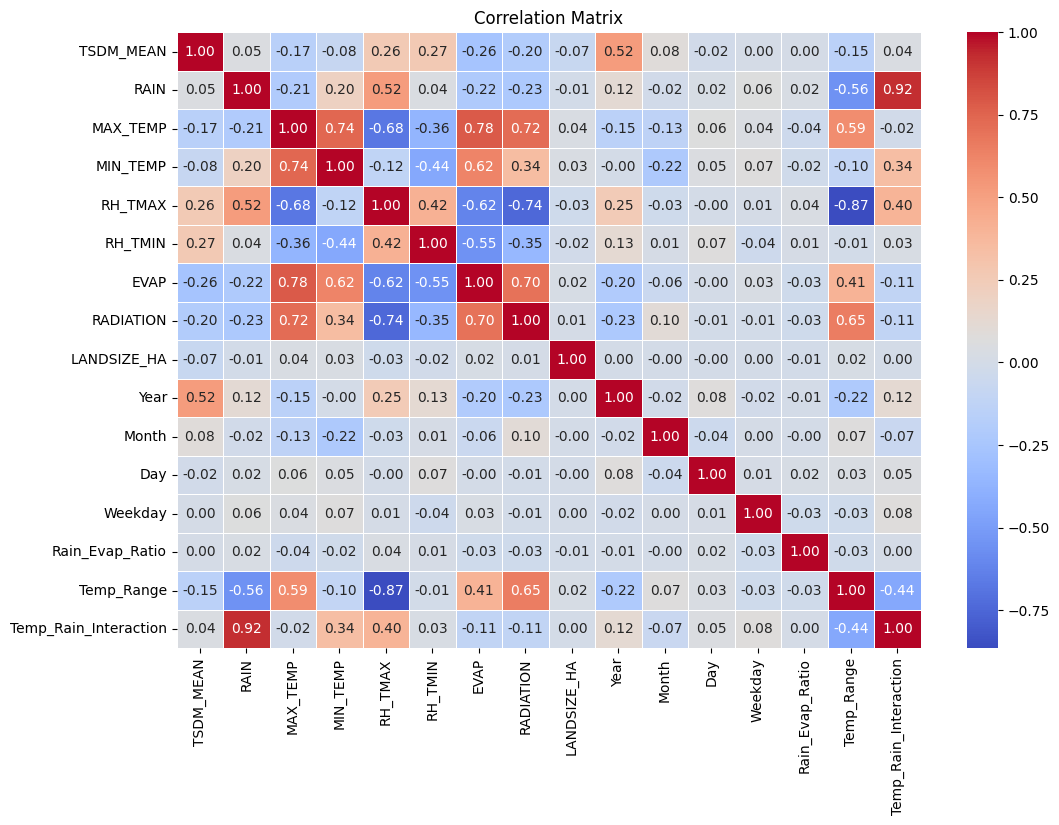

In [76]:
# Plotting the heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [77]:
target_correlations = correlation_matrix['TSDM_MEAN'].sort_values(ascending=False)

print("Feature Correlations with TSDM_MEAN:")

print(target_correlations)

Feature Correlations with TSDM_MEAN:
TSDM_MEAN                1.000000
Year                     0.519108
RH_TMIN                  0.268196
RH_TMAX                  0.260854
Month                    0.081826
RAIN                     0.045899
Temp_Rain_Interaction    0.040114
Weekday                  0.003450
Rain_Evap_Ratio          0.001939
Day                     -0.019178
LANDSIZE_HA             -0.072778
MIN_TEMP                -0.081271
Temp_Range              -0.147897
MAX_TEMP                -0.165543
RADIATION               -0.197527
EVAP                    -0.261396
Name: TSDM_MEAN, dtype: float64


### 5.2 Univariate feature selection

In [80]:
X = numeric_data.drop(columns=['TSDM_MEAN'])  # Features
y = numeric_data['TSDM_MEAN']  # Target variable

# Univariate feature selection 

selector = SelectKBest(score_func=f_regression, k=11)  
X_selected = selector.fit_transform(X, y)

# Get the selected features

selected_features = X.columns[selector.get_support()]

print("Selected Features from Univariate Selection:", selected_features)

Selected Features from Univariate Selection: Index(['RAIN', 'MAX_TEMP', 'MIN_TEMP', 'RH_TMAX', 'RH_TMIN', 'EVAP',
       'RADIATION', 'LANDSIZE_HA', 'Year', 'Month', 'Temp_Range'],
      dtype='object')


# Step 6: Modelling

In [82]:
# Target variable

y = numeric_data['TSDM_MEAN']  # Target variable

# Selected features

selected_feature = [
    'Year',
    'LANDSIZE_HA',
    'Month',
    'MIN_TEMP',
    'RH_TMAX',
    'RADIATION',
    'MAX_TEMP',
    'Temp_Range'
]

X_selected_df = numeric_data[selected_feature]

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X_selected_df, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [83]:
# Make predictions

y_pred = rf_model.predict(X_test)

# Evaluate the model

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE is the square root of MSE
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'R-squared (R²): {r2}')

Mean Squared Error (MSE): 0.2955450524198679
Root Mean Squared Error (RMSE): 0.5436405544289976
Mean Absolute Error (MAE): 0.3948207840001159
R-squared (R²): 0.7029498300541566


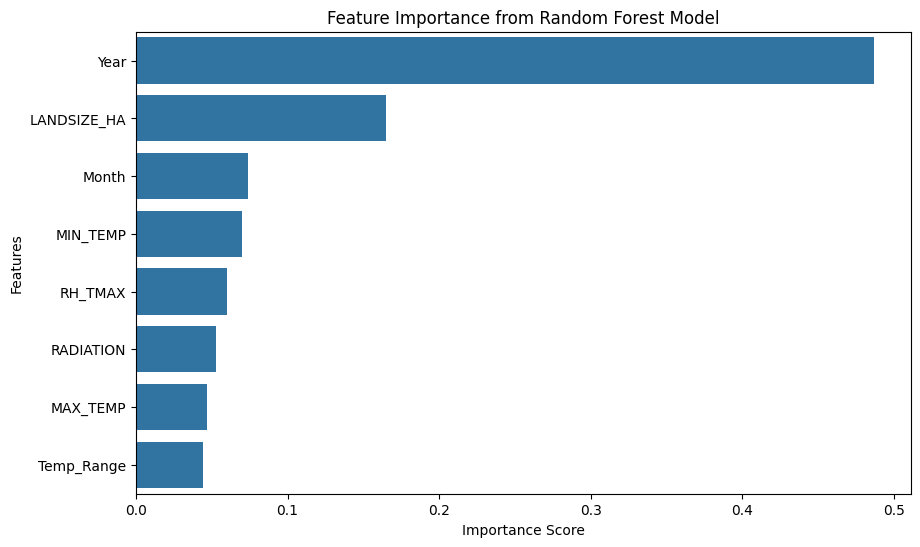

In [85]:
# Feature importances from the trained model
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

# Bar plot
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [87]:
# Target variable

y = numeric_data['TSDM_MEAN']  # Target variable

# Selected features

selected_feature = [
    'Year',
    'LANDSIZE_HA',
    'Month',
    'MIN_TEMP',
    'RH_TMAX',
    'RADIATION',
    'MAX_TEMP',
    'Temp_Range'
]

X_selected_df = numeric_data[selected_feature]

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X_selected_df, y, test_size=0.2, random_state=42)

# Initialize and train the XGBoost Regressor

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [88]:
# Make predictions

y_pred = xgb_model.predict(X_test)

# Evaluate the model

mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE is the square root of MSE
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics

print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'R-squared (R²): {r2}')

Mean Squared Error (MSE): 0.32986957000338885
Root Mean Squared Error (RMSE): 0.5743427286937555
Mean Absolute Error (MAE): 0.43359789433734675
R-squared (R²): 0.6684505085530514


In [ ]:
# Define the model
rf_model = RandomForestRegressor()

# Define the parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf_model,
                                   param_distributions=param_dist,
                                   n_iter=100,  # Number of iterations
                                   scoring='neg_mean_squared_error',
                                   cv=5,  # 5-fold cross-validation
                                   verbose=1,
                                   n_jobs=-1,  # Use all available cores
                                   random_state=42)

# Fit the random search to the data
random_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = random_search.best_params_
best_score = random_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score (MSE): {-best_score}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
